In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [5]:
from GridMaze.analysis.core import get_clusters as gc

## example cells

In [38]:
example_clusters = [
    "m6.2022-07-02.maze_cluster89",  # left pre
    "m6.2022-07-02.maze_cluster60",  # right pre
    "m6.2022-07-01.maze_cluster116",  # left on
    "m8.2022-07-01.maze_cluster53",  # right on
    "m3.2022-07-15.maze_cluster105",  # left post
    "m8.2022-06-28.maze_cluster26",  # right post
]

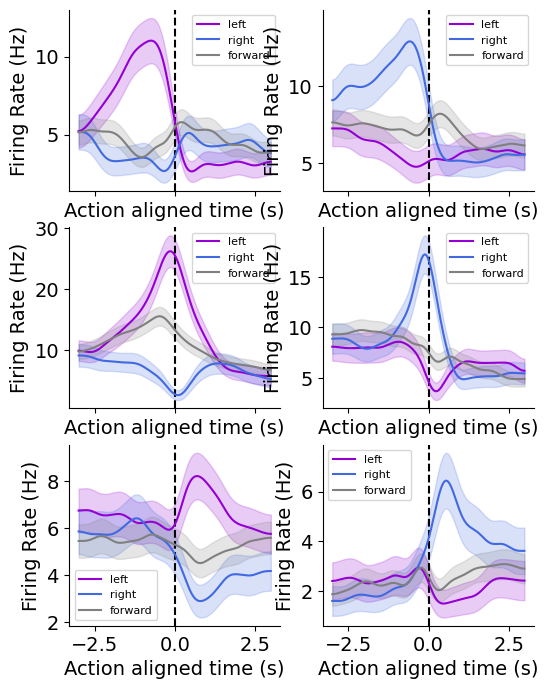

In [42]:
f, axes = plt.subplots(3, 2, figsize=(6, 8), clear=True, sharex=True)
for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(
        feature="actions",
        feature_kwargs={
            "concise": True,
            "action_type": "all",
            "smooth_SD": 14,
            "colors": ["darkviolet", "royalblue", "grey"],
        },
        ax=ax,
    )
f.savefig("../results/egocentric_action/example_cells.pdf")

## population heatmap

In [ ]:
from experiment.code.GridMaze.analysis.egocentric_action import population_tuning as pt

In [ ]:
tuning_df, metrics_df = pt.get_population_egocentric_action_tuning()

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.egocentricActionTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.egocentricActionTuningMetrics.parquet not found for m8.2022-07-26.maze


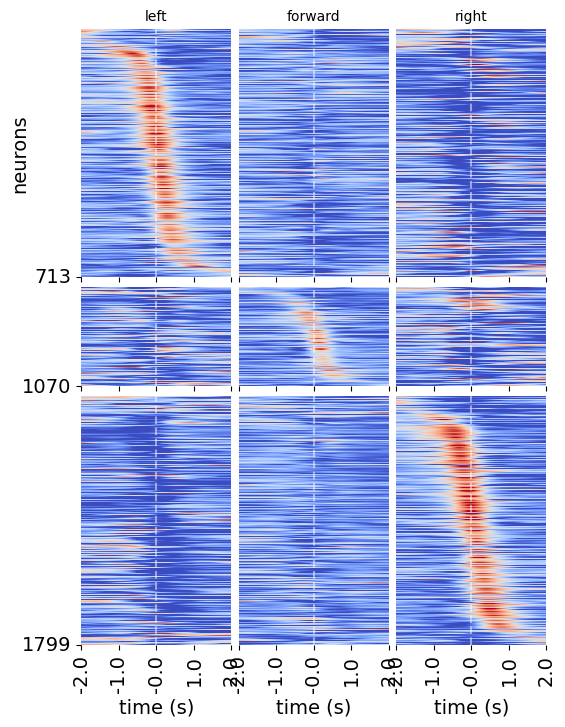

In [ ]:
# plot heatmap of action-aligned cells
reload(pt)
f, axes = plt.subplots(3, 3, figsize=(6, 8), height_ratios=[1, 0.4, 1], sharex=True)
pt.plot_egocentric_action_tuning_heatmap(tuning_df, metrics_df, axes=axes, f=f)
f.savefig("../results/egocentric_action/population_heatmap.pdf")

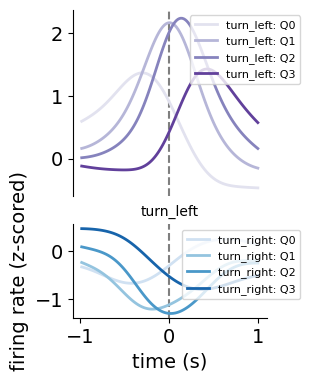

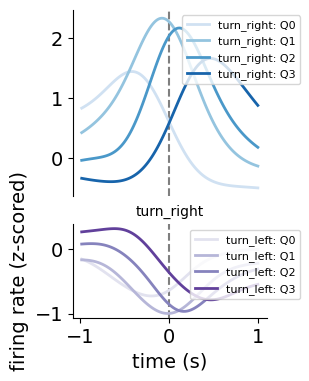

In [ ]:
# plot quartiles of these heatmaps to visualise the distribution of tuning relative to action
for action in ["turn_left", "turn_right"]:
    f, axes = plt.subplots(2, 1, figsize=(2.5, 4), height_ratios=[1, 0.5], sharex=False)
    pt.plot_heatmap_quantiles(tuning_df, metrics_df, pref_action=action, n_quantiles=4, axes=axes)
    f.savefig(f"../results/egocentric_action/{action}_heatmap_quantiles.pdf")

## vis population dynamics

In [ ]:
from GridMaze.analysis.egocentric_action import dynamics as edy

In [4]:
activity_df, metrics_df = edy.get_population_tuning_df()

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.egocentricActionTuningMetrics.parquet not found for m3.2022-06-25.maze


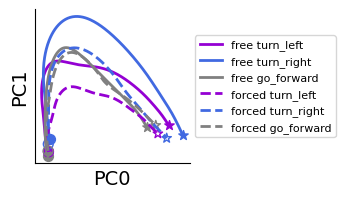

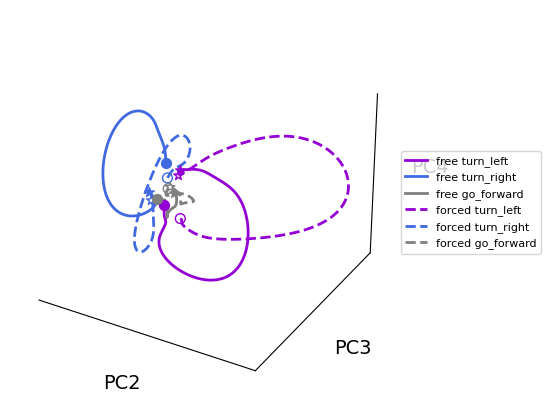

In [9]:
reload(edy)
PC_set_1 = (0, 1)
f, ax = edy._init_2D_plot(PC_set_1, figsize=(2, 2))
edy.PC_plot(activity_df, metrics_df, PCs=PC_set_1, f=f, ax=ax)
f.savefig("../results/egocentric_action/dynamics_1.pdf")

PC_set_2 = (2, 3, 4)
f, ax = edy._init_3D_plot(PC_set_1, figsize=(5, 5))
edy.PC_plot(activity_df, metrics_df, PCs=PC_set_1, f=f, ax=ax)
f.savefig("../results/egocentric_action/dynamics_2.pdf")

## unit match

In [ ]:
# plot some example matched clusters
example_matched_clusters = [
    ("m2.2022-07-05.maze_cluster59", "m2.2022-07-13.maze_cluster52"),
    ("m2.2022-07-04.maze_cluster77", "m2.2022-07-10.maze_cluster60"),
    ("m6.2022-07-03.maze_cluster81", "m6.2022-07-09.maze_cluster77"),
    ("m2.2022-07-15.maze_cluster93", "m2.2022-07-25.maze_cluster92"),
]

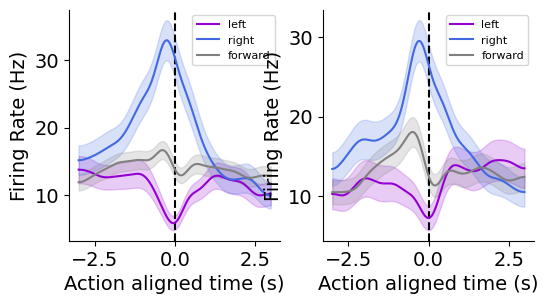

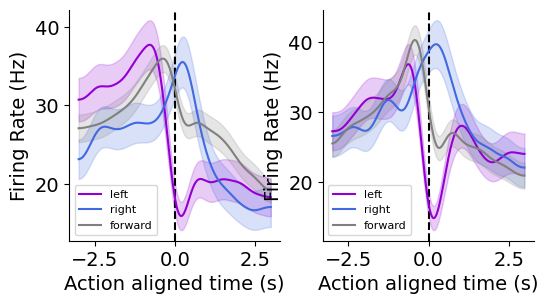

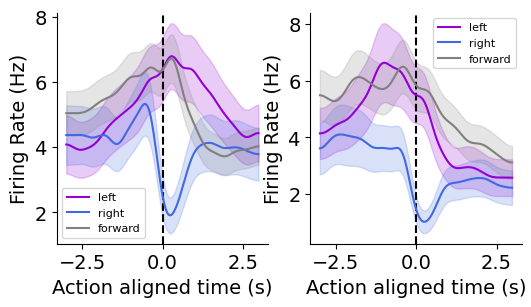

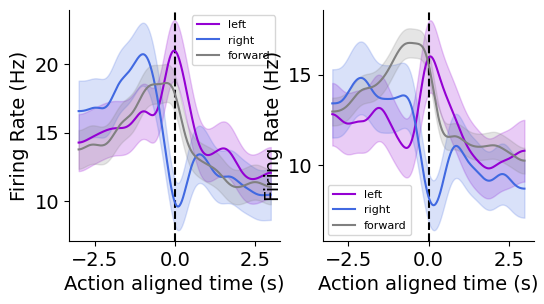

In [10]:
for pair in example_matched_clusters:
    f, axes = plt.subplots(1, 2, figsize=(6, 3))
    for cluster, ax in zip(pair, axes):
        Clust = gc.get_cluster(cluster)
        Clust.plot_tuning(
            feature="actions",
            feature_kwargs={
                "concise": True,
                "action_type": "all",
                "smooth_SD": 14,
                "colors": ["darkviolet", "royalblue", "grey"],
            },
            ax=ax,
        )

In [4]:
from GridMaze.analysis.unit_match import egocentric_action as um_ea

Subject p-values:
   p_value
m2     0.0
m3     0.0
m4     0.0
m6     0.0
m7   0.011
m8     0.0
Random effects t-statistic: 6.057, p-value: 0.002
Subject p-values:
   p_value
m2     0.0
m3     0.0
m4     NaN
m6     0.0
m7     0.0
m8     0.2
Random effects t-statistic: 6.082, p-value: 0.004


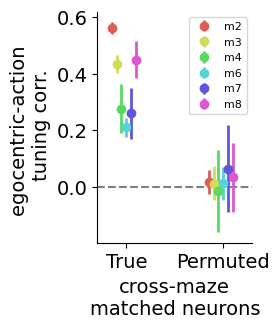

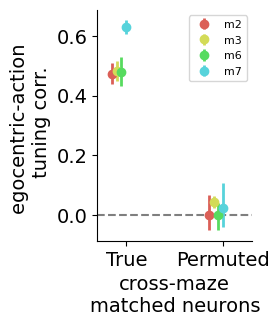

In [ ]:
# plot summary stats correlating tuning curves across mazes
for maze_pair in [("maze_1", "maze_2"), ("maze_2", "rooms_maze")]:
    results = um_ea.get_cross_maze_corr_summary(maze_pair=maze_pair)
    um_ea.plot_cross_maze_corrs_summary(results, print_stats=True, min_matches=10)

In [9]:
# we can even revisit our tuning heatmaps but now looking at units matched across mazes
A, B = um_ea.get_matched_egocentric_action_tuning_df(
    min_split_half_corr=0.3,
    min_pref_action_factor=2,
    min_pref_action_frac=0.5,
    verbose=False,
)

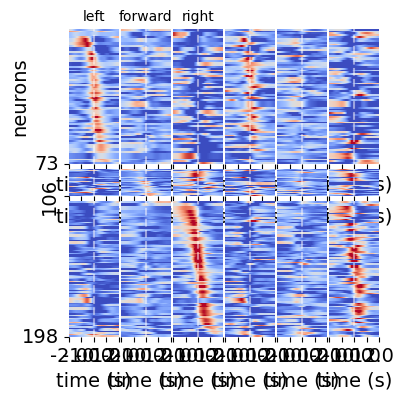

In [10]:
reload(um_ea)
f, axes = plt.subplots(3, 6, figsize=(4, 4), height_ratios=[1, 0.2, 1], sharex=True)
um_ea.plot_matched_egocentric_action_tuning_heatmap(A, B, fig=f, axes=axes)

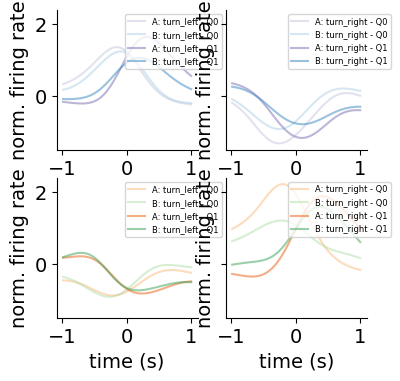

In [11]:
f, axes = plt.subplots(2, 2, figsize=(4, 4), sharex=False, sharey=True)
um_ea.plot_matched_heatmap_quantiles(A, B, axes=axes)